In [1]:
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
from torch_lr_finder import LRFinder
from torch.utils.data import random_split, TensorDataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

def set_seed(seed):
    torch.manual_seed(seed)

set_seed(42)

/opt/anaconda3/envs/py39/lib/python3.9/site-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def split_data_to_tensors(df: pd.DataFrame, target_col: str):
    SEED = 42 

    X_raw = df.drop(columns=[target_col]).values
    y_raw = df[target_col].values
    
    X_tensor = torch.tensor(X_raw, dtype=torch.float32)
    y_tensor = torch.tensor(y_raw, dtype=torch.float32).view(-1, 1)
    
    full_dataset = TensorDataset(X_tensor, y_tensor)
    
    data_size = len(full_dataset)
    train_size = int(0.6 * data_size)
    val_size = int(0.2 * data_size)
    test_size = data_size - train_size - val_size
    
    generator = torch.Generator().manual_seed(SEED)
    train_subset, val_subset, test_subset = random_split(
        dataset=full_dataset, 
        lengths=[train_size, val_size, test_size], 
        generator=generator
    )

    def extract_fast(subset: Subset):
        indices = subset.indices

        X_extracted = subset.dataset.tensors[0][indices]
        y_extracted = subset.dataset.tensors[1][indices]
        return X_extracted, y_extracted

    X_train, y_train = extract_fast(train_subset)
    X_val, y_val = extract_fast(val_subset)
    X_test, y_test = extract_fast(test_subset)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [3]:
data = pd.read_csv('../data/features.csv')
drop_list = ['id', 'pop']
data = data.drop(columns=drop_list)
data.head()

,esalc_190_avg,esalc_160_avg,esalc_150_avg,esalc_140_avg,esalc_130_avg,esalc_40_avg,esalc_11_avg,wdpa_dist_avg,coastline_dist_avg,inland_water_dist_avg,waterbodies_dist_avg,road_intr_dist_avg,highway_dist_avg,elevation_avg,nightlights_avg,built_v_avg,built_s_avg,dens
0,1.573989,5.598381,81.149541,19.855016,2.267903,8.298236,-0.501676,206.168256,12.312423,0.275400,0.287997,1.119921,0.256646,5.430791,1.420532,3519.231356,584.990113,10.818079
1,1.471743,5.421828,83.426638,22.082827,4.323926,8.810693,-0.580130,212.090280,13.450801,0.428536,0.468018,1.688639,0.383947,4.527738,1.214360,1426.663798,400.594878,9.182676
2,1.337847,1.167826,68.900829,29.250456,0.922751,2.947074,-0.345495,191.134523,7.951794,0.435511,0.423092,0.744012,0.230053,6.642586,1.356961,2606.523087,656.186016,15.336412
3,1.783236,1.619139,73.098324,25.231087,2.381500,1.590991,-0.615545,191.590394,11.897428,0.395001,0.344558,2.212710,0.398853,6.505012,0.717990,1050.509887,366.640914,7.869515
4,0.689970,1.975611,70.391644,27.993768,1.218443,2.285939,-0.495957,190.280447,9.888428,0.538464,0.528630,0.864468,0.252128,6.445289,2.888520,3685.346097,778.625000,18.383399


In [4]:
TARGET_COL = 'dens'

X_train, y_train, X_val, y_val, X_test, y_test = split_data_to_tensors(data, TARGET_COL)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape} | y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

X_train shape: torch.Size([6696, 17]) | y_train shape: torch.Size([6696, 1])
X_val shape: torch.Size([2232, 17]) | y_val shape: torch.Size([2232, 1])
X_test shape: torch.Size([2233, 17]) | y_test shape: torch.Size([2233, 1])


In [5]:
scaler = StandardScaler()
X_train_scaled_np = scaler.fit_transform(X_train)
X_val_scaled_np = scaler.transform(X_val)
X_test_scaled_np = scaler.transform(X_test)

X_train_scaled = torch.tensor(X_train_scaled_np, dtype=torch.float32, requires_grad=True)
X_val_scaled = torch.tensor(X_val_scaled_np, dtype=torch.float32, requires_grad=True)
X_test_scaled = torch.tensor(X_test_scaled_np, dtype=torch.float32, requires_grad=True)

y_train_log = torch.log1p(y_train)
y_val_log = torch.log1p(y_val)
y_test_log = torch.log1p(y_test)

In [6]:
train_data = TensorDataset(X_train_scaled, y_train_log)
val_data = TensorDataset(X_val_scaled, y_val_log)
test_data = TensorDataset(X_test_scaled, y_test_log)

BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)


In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


model = nn.Sequential(
    nn.Linear(17, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    
    nn.Linear(32, 1)
)

model = model.to(device)

print(model)

model.train()

loss_func = nn.SmoothL1Loss()

optimizer = optim.Adam(model.parameters(), lr=1e-5)

Sequential(
  (0): Linear(in_features=17, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


  0%|          | 0/200 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
iteration: 200
LR suggestion: steepest gradient
Suggested LR: 2.41E-03


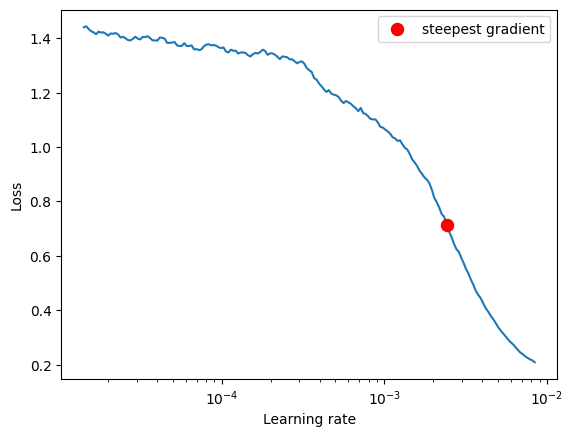

In [8]:
lr_finder = LRFinder(
    model, 
    optimizer, 
    loss_func, 
    device='cpu'
    )  

lr_finder.range_test(train_loader, end_lr=1e-2, num_iter=200, diverge_th=5) # type: ignore

print(f"iteration: {len(lr_finder.history['loss'])}")

lr_finder.plot()

lr_finder.reset()

In [ ]:
EPOCH_NUM = 100
optimizer = optim.Adam(model.parameters(), lr=1e-03)

model.train()

for i in range(EPOCH_NUM):


    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        
        optimizer.zero_grad()

        output = model(data)

        loss = loss_func(output, label)
        loss.backward()
        
        optimizer.step()
        
    if (i + 1) % 10 == 0:
        print(f"Epoch {i+1}/{EPOCH_NUM} | Train Loss: {loss.item():.4f}")


Epoch 10/100 | Train Loss: 0.2024
Epoch 20/100 | Train Loss: 0.0391
Epoch 30/100 | Train Loss: 0.0480
Epoch 40/100 | Train Loss: 0.0416


In [ ]:
model.eval()

test_loss = 0.0
correct, total = 0, 0

with torch.no_grad():
    for data, label in test_loader:
        data, label = data.to(device), label.to(device)

        output = model(data)

        loss = loss_func(output, label)

        test_loss += loss.item() * data.size(0)

        label = torch.expm1(label)
        output = torch.expm1(output)

        total += label.size(0)
        correct += (((output - label)/label).abs() < 0.15).sum().item()  

print(f"Test Loss: {test_loss / total:.4f} | Accuracy: {(correct / total * 100):.2f}%")
print(f"Correct Predictions: {correct} | Total Predictions: {total}")


Test Loss: 0.0353 | Accuracy: 38.60%
Correct Predictions: 862 | Total Predictions: 2233
